# Stack Overflow Survey Cleaning (2015-2025)

This notebook uses the EDA findings and for a cleaning pass focused on respondent overviews, cross-year change, regional analysis, and a creating compensation ready baseline.

## Plan

- rebuild the cross-year respondent table
- make cohort denominators explicit
- clean the messiest fields from EDA
- leave a respondent-level `clean_core` table ready for later analysis and modeling

In [1]:
import logging
import re
import warnings
from pathlib import Path

import country_converter as coco
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Multiple packages create lots of unnecessary warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')
logging.getLogger('country_converter').setLevel(logging.ERROR)
logging.getLogger('country_converter.country_converter').setLevel(logging.ERROR)

# Set display defaults for pandas, seaborn, and matplotlib
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120


def find_root():
    here = Path.cwd()
    for path in [here, *here.parents]:
        if (path / 'data').exists():
            return path
    raise FileNotFoundError("Could not find project root")


ROOT = find_root()
DATA_DIR = ROOT / 'data'

print(ROOT)

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis


More complete mapping of where different useful analysis columns exist in the different years. This is not 100% locked down so I welcome any additions

In [2]:
YEAR_INFO = {2015: {'file': '2015 Stack Overflow Developer Survey Responses.csv',
        'header': 1,
        'response_id': None,
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': None,
        'main_branch': None,
        'student': None,
        'employment': 'Employment Status',
        'education': None,
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': None,
        'dev_type': 'Occupation',
        'industry': 'Industry',
        'remote': 'Remote Status',
        'years_code': 'Years IT / Programming Experience',
        'years_code_pro': None,
        'work_exp': None,
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'Compensation: midpoint',
        'job_sat': 'Job Satisfaction',
        'language': None,
        'database': None,
        'platform': None,
        'webframe': None,
        'misc_tech': None,
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2016: {'file': '2016 Stack Overflow Survey Responses.csv',
        'header': 0,
        'response_id': None,
        'country': 'country',
        'age': 'age_midpoint',
        'gender': 'gender',
        'ethnicity': None,
        'main_branch': None,
        'student': None,
        'employment': 'employment_status',
        'education': 'education',
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': 'company_size_range',
        'dev_type': 'occupation',
        'industry': 'industry',
        'remote': 'remote',
        'years_code': 'experience_range',
        'years_code_pro': 'experience_range',
        'work_exp': None,
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'salary_midpoint',
        'job_sat': 'job_satisfaction',
        'language': 'tech_do',
        'database': None,
        'platform': None,
        'webframe': None,
        'misc_tech': None,
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2017: {'file': 'survey_results_public2017.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': None,
        'gender': 'Gender',
        'ethnicity': None,
        'main_branch': 'Professional',
        'student': 'Professional',
        'employment': 'EmploymentStatus',
        'education': 'FormalEducation',
        'undergrad_major': 'MajorUndergrad',
        'age_first_code': None,
        'org_size': 'CompanySize',
        'dev_type': 'DeveloperType',
        'industry': 'CompanyType',
        'remote': 'HomeRemote',
        'years_code': 'YearsProgram',
        'years_code_pro': 'YearsCodedJob',
        'work_exp': None,
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'Salary',
        'job_sat': 'JobSatisfaction',
        'language': 'HaveWorkedLanguage',
        'database': 'HaveWorkedDatabase',
        'platform': 'HaveWorkedPlatform',
        'webframe': None,
        'misc_tech': None,
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2018: {'file': 'survey_results_public2018.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': 'RaceEthnicity',
        'main_branch': None,
        'student': 'Student',
        'employment': 'Employment',
        'education': 'FormalEducation',
        'undergrad_major': 'UndergradMajor',
        'age_first_code': None,
        'org_size': 'CompanySize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCoding',
        'years_code_pro': 'YearsCodingProf',
        'work_exp': None,
        'job_seek': 'JobSearchStatus',
        'work_week_hrs': None,
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'ConvertedSalary',
        'job_sat': 'JobSatisfaction',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'webframe': None,
        'misc_tech': None,
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': 'AIFuture'},
 2019: {'file': 'survey_results_public2019.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': 'Ethnicity',
        'main_branch': 'MainBranch',
        'student': 'Student',
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': 'UndergradMajor',
        'age_first_code': 'Age1stCode',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'WorkRemote',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'job_seek': 'JobSeek',
        'work_week_hrs': 'WorkWeekHrs',
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'webframe': 'WebFrameWorkedWith',
        'misc_tech': 'MiscTechWorkedWith',
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2020: {'file': 'survey_results_2020.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': 'Ethnicity',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': 'UndergradMajor',
        'age_first_code': 'Age1stCode',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'job_seek': 'JobSeek',
        'work_week_hrs': 'WorkWeekHrs',
        'learn_code': None,
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'webframe': 'WebframeWorkedWith',
        'misc_tech': 'MiscTechWorkedWith',
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2021: {'file': 'survey_results_2021.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': 'Ethnicity',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': None,
        'age_first_code': 'Age1stCode',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': 'LearnCode',
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'webframe': 'WebframeHaveWorkedWith',
        'misc_tech': 'MiscTechHaveWorkedWith',
        'op_sys_prof': None,
        'ai_use': None,
        'ai_sent': None},
 2022: {'file': 'survey_results_2022.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'ethnicity': 'Ethnicity',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': 'LearnCode',
        'learn_code_online': 'LearnCodeOnline',
        'coding_activities': 'CodingActivities',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'webframe': 'WebframeHaveWorkedWith',
        'misc_tech': 'MiscTechHaveWorkedWith',
        'op_sys_prof': 'OpSysProfessional use',
        'ai_use': None,
        'ai_sent': None},
 2023: {'file': 'survey_results_2023.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'ethnicity': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': 'LearnCode',
        'learn_code_online': 'LearnCodeOnline',
        'coding_activities': 'CodingActivities',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'webframe': 'WebframeHaveWorkedWith',
        'misc_tech': 'MiscTechHaveWorkedWith',
        'op_sys_prof': 'OpSysProfessional use',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'},
 2024: {'file': 'survey_results_2024.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'ethnicity': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': 'LearnCode',
        'learn_code_online': 'LearnCodeOnline',
        'coding_activities': 'CodingActivities',
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'webframe': 'WebframeHaveWorkedWith',
        'misc_tech': 'MiscTechHaveWorkedWith',
        'op_sys_prof': 'OpSysProfessional use',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'},
 2025: {'file': 'survey_results_2025.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'ethnicity': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'undergrad_major': None,
        'age_first_code': None,
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': None,
        'work_exp': 'WorkExp',
        'job_seek': None,
        'work_week_hrs': None,
        'learn_code': 'LearnCode',
        'learn_code_online': None,
        'coding_activities': None,
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'webframe': 'WebframeHaveWorkedWith',
        'misc_tech': None,
        'op_sys_prof': 'OpSysProfessional use',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'}}

YEARS = sorted(YEAR_INFO)
YEARS

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

## Cross-Year Load and Light Unification

Begins building are single DataFrame and standardization of responses.

In [3]:
# The 2015 data had the brilliant idea of splitting each multi-select value into its own column. That created a headache.
EDU_2015_LEVELS = [
    ('No formal education / other', 'Training & Education: No formal training'),
    ('Some college/university', 'Training & Education: Some college, but no CS degree'),
    ("Bachelor's degree", 'Training & Education: BS in CS'),
    ("Master's degree", 'Training & Education: Masters in CS'),
    ('Doctoral degree', 'Training & Education: PhD in CS')
]

LANG_2015 = [
    'C',
    'C++',
    'C++11',
    'C#',
    'Clojure',
    'CoffeeScript',
    'Dart',
    'F#',
    'Go',
    'Haskell',
    'Java',
    'JavaScript',
    'Matlab',
    'Objective-C',
    'Perl',
    'PHP',
    'Python',
    'R',
    'Ruby',
    'Rust',
    'Scala',
    'SQL',
    'Swift',
    'Visual Basic'
]

DB_2015 = [
    'Cassandra',
    'MongoDB',
    'Redis',
    'SQL Server'
]

PLATFORM_2015 = [
    'Android',
    'AngularJS',
    'Arduino',
    'Cloud',
    'Cordova',
    'Hadoop',
    'iOS',
    'LAMP',
    'Node.js',
    'Salesforce',
    'Sharepoint',
    'Spark',
    'Windows Phone',
    'Wordpress'
]

TECH_2015_ALL = LANG_2015 + DB_2015 + PLATFORM_2015


# Many values are ranges with different formatting; this should handle all formats and convert it to a single average value
def parse_midpoint(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    lower = text.lower()
    numbers = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', text.replace(',', ''))]

    if not numbers:
        return np.nan
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    if 'under' in lower or text.startswith('<'):
        return max(numbers[0] - 1, 0)
    return numbers[0]


# Joins the separated response values into a single column
def join_selected(df, labels):
    cols = [f'Current Lang & Tech: {label}' for label in labels]
    flags = df.reindex(columns=cols).notna()
    parts = []
    for label in labels:
        col = f'Current Lang & Tech: {label}'
        parts.append(flags[col].map({True: label, False: pd.NA}))
    return pd.concat(parts, axis=1).apply(lambda row: ';'.join(row.dropna().astype(str)), axis=1).replace('', pd.NA)


# Creates the 2015 DataFrame separately due to the comlications with the setup
def build_2015_fields(df):
    education = pd.Series(pd.NA, index=df.index, dtype='object')
    for label, col in EDU_2015_LEVELS:
        part = df[col].notna().map({True: label, False: pd.NA})
        education = education.fillna(part)

    language = join_selected(df, LANG_2015)
    database = join_selected(df, DB_2015)
    platform = join_selected(df, PLATFORM_2015)

    write_in = df.get('Current Lang & Tech: Write-In', pd.Series(pd.NA, index=df.index)).replace('', pd.NA)
    current_tech = pd.concat([join_selected(df, TECH_2015_ALL), write_in], axis=1).apply(lambda row: ';'.join(row.dropna().astype(str)), axis=1).replace('', pd.NA)

    return pd.DataFrame({
        'education': education,
        'language': language,
        'database': database,
        'platform': platform,
        'current_tech': current_tech
    })


# Helper to quickly pull in the desired columns for a given year
def read_year(year, columns):
    info = YEAR_INFO[year]
    path = DATA_DIR / info['file']
    return pd.read_csv(
        path,
        header=info['header'],
        usecols=lambda col: col in columns,
        low_memory=False
    )


# Takes all the years and makes a unified DataFrame with a standardized format
def load_year(year):
    info = YEAR_INFO[year]
    fields = [
        'response_id',
        'country',
        'age',
        'gender',
        'ethnicity',
        'main_branch',
        'student',
        'employment',
        'education',
        'undergrad_major',
        'age_first_code',
        'org_size',
        'dev_type',
        'industry',
        'remote',
        'years_code',
        'years_code_pro',
        'work_exp',
        'job_seek',
        'work_week_hrs',
        'learn_code',
        'learn_code_online',
        'coding_activities',
        'comp',
        'job_sat',
        'language',
        'database',
        'platform',
        'webframe',
        'misc_tech',
        'op_sys_prof',
        'ai_use',
        'ai_sent'
    ]
    selected = [info[field] for field in fields if info[field] is not None]

    if year == 2015:
        selected += [col for _, col in EDU_2015_LEVELS]
        selected += [f'Current Lang & Tech: {label}' for label in TECH_2015_ALL]
        selected += ['Current Lang & Tech: Write-In']

    selected = list(dict.fromkeys(selected))
    df = read_year(year, selected)

    out = pd.DataFrame(index=df.index)
    out['row_id'] = year * 1_000_000 + np.arange(len(df))
    out['survey_year'] = year

    for field in fields:
        raw_col = info[field]
        out[field] = df[raw_col] if raw_col in df.columns else pd.NA

    out['current_tech'] = pd.NA

    if year == 2015:
        derived = build_2015_fields(df)
        for col in derived.columns:
            out[col] = derived[col]

    out['age_num'] = out['age'].map(parse_midpoint)
    out['age_first_code_num'] = out['age_first_code'].map(parse_midpoint)
    out['years_code_num'] = out['years_code'].map(parse_midpoint)
    out['years_code_pro_num'] = out['years_code_pro'].map(parse_midpoint)
    out['work_exp_num'] = out['work_exp'].map(parse_midpoint)
    out['work_week_hrs_num'] = pd.to_numeric(out['work_week_hrs'], errors='coerce')
    out['comp_usd'] = out['comp'].map(parse_midpoint)
    out['job_sat_num'] = pd.to_numeric(out['job_sat'], errors='coerce')

    return out


# Displays a sample of the built unified frame before cleaning
core = pd.concat([load_year(year) for year in YEARS], ignore_index=True)
print(core.shape)
display(core.sample(8, random_state=42))

core_raw = core.copy()

(746226, 44)


,row_id,survey_year,response_id,country,age,gender,ethnicity,main_branch,student,employment,education,undergrad_major,age_first_code,org_size,dev_type,industry,remote,years_code,years_code_pro,work_exp,job_seek,work_week_hrs,learn_code,learn_code_online,coding_activities,comp,job_sat,language,database,platform,webframe,misc_tech,op_sys_prof,ai_use,ai_sent,current_tech,age_num,age_first_code_num,years_code_num,years_code_pro_num,work_exp_num,work_week_hrs_num,comp_usd,job_sat_num
660422,2024028824,2024,28825,Thailand,25-34 years old,NaN,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,NaN,10 to 19 employees,"Developer, full-stack",NaN,In-person,8,1,NaN,NaN,NaN,"Colleague;On the job training;School (i.e., Un...",NaN,Hobby,NaN,NaN,C#;HTML/CSS;JavaScript;SQL,MariaDB;MongoDB;MySQL,NaN,ASP.NET;ASP.NET CORE;jQuery;Node.js;Vue.js,.NET (5+) ;.NET Framework (1.0 - 4.8),Windows,Yes,Favorable,NaN,29.5,NaN,8.0,1.0,NaN,NaN,NaN,NaN
115194,2017033078,2017,33079,New Zealand,NaN,NaN,NaN,Student,Student,"Not employed, and not looking for work",Secondary school,NaN,NaN,NaN,NaN,NaN,NaN,2 to 3 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN
462718,2021077011,2021,77012,Denmark,35-44 years old,Man,White or of European descent,I am a developer by profession,NaN,Employed full-time,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,5 - 10 years,20 to 99 employees,"Developer, desktop or enterprise applications;...",NaN,NaN,30,20,NaN,NaN,NaN,School;Other (please specify):;Books / Physica...,NaN,NaN,118104.0,NaN,Clojure;Haskell;Kotlin,DynamoDB;PostgreSQL;SQLite,AWS;DigitalOcean,React.js,NaN,NaN,NaN,NaN,NaN,39.5,7.5,30.0,20.0,NaN,NaN,118104.0,NaN
683102,2024051504,2024,51505,United States of America,25-34 years old,NaN,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,NaN,"5,000 to 9,999 employees","Developer, back-end",Software Development,"Hybrid (some remote, some in-person)",14,6,6.0,NaN,NaN,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,I don’t code outside of work,NaN,7.0,Java,MySQL,Amazon Web Services (AWS),Spring Boot,Spring Framework,MacOS,"No, and I don't plan to",NaN,NaN,29.5,NaN,14.0,6.0,6.0,NaN,NaN,7.0
116754,2017034638,2017,34639,United States,NaN,NaN,NaN,Professional developer,Professional developer,Employed full-time,Bachelor's degree,Computer science or software engineering,NaN,100 to 499 employees,Web developer,"Privately-held limited company, not in startup...",All or almost all the time (I'm full-time remote),14 to 15 years,8 to 9 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.5,8.5,NaN,NaN,NaN,6.0
533507,2022064361,2022,64362,United States of America,55-64 years old,Man,White;North American,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,NaN,100 to 499 employees,"Developer, back-end;Other (please specify):",NaN,"Hybrid (some remote, some in-person)",32,28,28.0,NaN,NaN,"Books / Physical media;School (i.e., Universit...",NaN,I don’t code outside of work,116000.0,NaN,C#;PowerShell;SQL,Microsoft SQL Server,Microsoft Azure,ASP.NET;ASP.NET Core,NaN,Windows,NaN,NaN,NaN,59.5,NaN,32.0,28.0,28.0,NaN,116000.0,NaN
298513,2019066150,2019,66571,United States,21.0,Man,White or of European descent,I am a developer by profession,No,Employed full-time,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",10,100 to 499 employees,"Developer, desktop or enterprise applications;...",NaN,Less than once per month / Never,6,1,NaN,I am not interested in new job opportunities,40.0,NaN,NaN,NaN,51000.0,Very satisfied,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript,NaN,Windows,Angular/Angular.js;jQuery,NaN,NaN,NaN,NaN,NaN,21.0,10.0,6.0,1.0,NaN,40.0,51000.0,NaN
199246,2018065738,2018,93313,Ger

## Programming Language Trends Revisited

Went back and looked at the changes in programming language usage over time. The two biggest changes from the original are:
- including `core_notna = core.loc[core['language'].notna(), ['row_id', 'survey_year', 'language']]` which makes sure we're only looking at records that actually have a response for the language category, otherwise some years with lots of nulls will skew results
- using `df_lang['language'] = df_lang['language'].str.strip()` to remove whitespace from responses after they've been separated. One of the years has a second value for each language with whitespace (i.e "CSS" and " CSS") which makes it seem like they have far fewer responses

Beyond that, everything else was added to standardize the values to a single format so they're the same across all years and to remove responses that have tech other than programming languages.

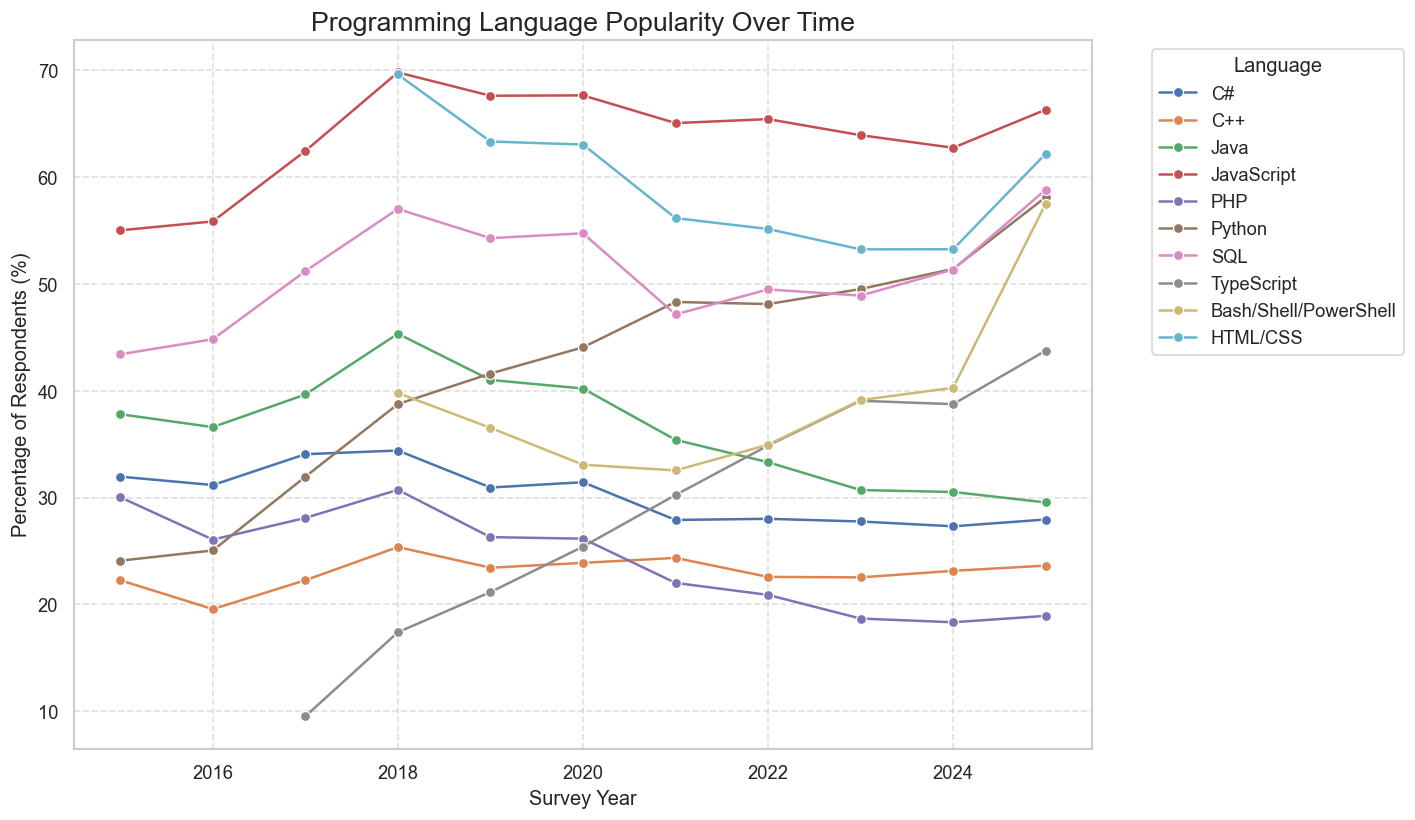

In [4]:
PLAT_2016 = [
    'Android',
    'Arduino / Raspberry Pi',
    'Cloud (AWS, GAE, Azure, etc.)',
    'Cordova',
    'Hadoop',
    'LAMP',
    'Node.js',
    'Salesforce',
    'SharePoint',
    'Spark',
    'Windows Phone',
    'WordPress',
    'iOS'
]

EXTRAS = [
    'AngularJS',
    'APT',
    'Ansible',
    'Bun',
    'Cargo',
    'Chocolatey',
    'Composer',
    'Datadog',
    'Flow',
    'Google Cloud Storage',
    'Gradle',
    'Homebrew',
    'MSBuild',
    'Make',
    'Maven (build tool)',
    'Microsoft Azure (Tables, CosmosDB, SQL, etc)',
    'New Relic',
    'Ninja',
    'NuGet',
    'Other(s):',
    'Pacman',
    'Pip',
    'Poetry',
    'Prometheus',
    'ReactJS',
    'Slack',
    'Slack Apps and Integrations',
    'Splunk',
    'Terraform',
    'Vite',
    'Webpack',
    'Yarn',
    'Zephyr',
    'npm',
    'pnpm'
]

# Only include responses that have a language listed so null responses don't bias results
core_notna = core.loc[core['language'].notna(), ['row_id', 'survey_year', 'language']]

# Handle the multi-value 'language' column
# Split the strings into lists and explode them into individual rows then strip whitespace
df_lang = core_notna.assign(language=core_notna['language'].str.split(';')).explode('language')
df_lang['language'] = df_lang['language'].str.strip()

# Some years included platforms and databases into their languages, filter them out
plat_dat_remove = DB_2015 + PLATFORM_2015 + PLAT_2016 + EXTRAS
df_lang = df_lang[~df_lang['language'].isin(plat_dat_remove)]

# Manually map languages that that aren't standardized across years
lang_map = {
    'C++11': 'C++',
    'Matlab': 'MATLAB',
    'Cobol': 'COBOL',
    'Ocaml': 'OCaml',
    'Delphi': 'Delphi/Object Pascal',
    'LISP': 'Lisp',
    'Common Lisp': 'Lisp',
    'Bash/Shell': 'Bash/Shell/PowerShell',
    'Bash/Shell (all shells)': 'Bash/Shell/PowerShell',
    'PowerShell': 'Bash/Shell/PowerShell',
    'HTML': 'HTML/CSS',
    'CSS': 'HTML/CSS',
    'Visual Basic (.Net)': 'VB.NET',
    'Visual Basic 6': 'Visual Basic'
}
df_lang['language'] = df_lang['language'].replace(lang_map)

# Some years has HTML and CSS as two entries, remove duplicates so HTML/CSS isn't counted twice there
df_lang = df_lang.drop_duplicates(['row_id','survey_year','language'])

# Calculate Popularity (Percentage of respondents per year)
# We group by year and language, then divide by the total number of unique respondents that year
yearly_totals = core_notna.groupby('survey_year')['row_id'].nunique().reset_index(name='year_total')
lang_counts = df_lang.groupby(['survey_year', 'language']).size().reset_index(name='count')

# Merge to get total respondents per year for percentage calculation
lang_trends = lang_counts.merge(yearly_totals, on='survey_year')
lang_trends['percentage'] = (lang_trends['count'] / lang_trends['year_total']) * 100

# Filter for Top 10 Languages (to keep the chart clean)
top_langs = lang_trends.groupby('language')['count'].sum().nlargest(10).index
lang_trends_filtered = lang_trends[lang_trends['language'].isin(top_langs)]

# Visualization
plt.figure(figsize=(12, 7))
sns.lineplot(data=lang_trends_filtered, x='survey_year', y='percentage', hue='language', marker='o')

plt.title('Programming Language Popularity Over Time', fontsize=16)
plt.ylabel('Percentage of Respondents (%)')
plt.xlabel('Survey Year')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Cohorts and Coverage

Explicity defines the analysis populations and field coverages before adding cleaning rules.

,rows,employed_share,professional_share
survey_year,,,
2015,26086,0.666,0.652
2016,56030,0.748,0.732
2017,51392,0.867,0.803
2018,98855,0.861,0.781
2019,88883,0.871,0.760
2020,64461,0.825,0.752
2021,83439,0.768,0.712
2022,73268,0.796,0.748
2023,89184,0.819,0.775


,country,age_num,gender,ethnicity,main_branch,employment,education,undergrad_major,age_first_code_num,org_size,dev_type,remote,years_code_num,years_code_pro_num,work_exp_num,job_seek,job_sat,work_week_hrs_num,learn_code,learn_code_online,coding_activities,language,database,platform,webframe,misc_tech,op_sys_prof,ai_use,ai_sent,comp_usd
survey_year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015,96.9,97.7,98.7,0.0,0.0,81.7,75.3,0.0,0.0,0.0,79.9,61.9,95.2,0.0,0.0,0.0,62.0,0.0,0.0,0.0,0.0,83.3,23.1,44.8,0.0,0.0,0.0,0.0,0.0,57.0
2016,99.1,98.8,99.2,0.0,0.0,88.5,80.2,0.0,0.0,71.3,88.4,71.6,88.4,88.4,0.0,0.0,71.6,0.0,0.0,0.0,0.0,87.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74.5
2017,100.0,0.0,68.2,0.0,100.0,100.0,100.0,83.4,0.0,75.7,70.3,85.6,96.6,73.7,0.0,0.0,78.6,0.0,0.0,0.0,0.0,71.3,57.3,56.7,0.0,0.0,0.0,0.0,0.0,25.1
2018,99.6,65.3,65.2,58.1,0.0,96.4,95.8,80.0,0.0,72.4,93.2,0.0,94.9,78.8,0.0,80.4,70.1,0.0,0.0,0.0,0.0,79.2,67.0,66.8,0.0,0.0,0.0,0.0,70.5,48.3
2019,99.9,89.1,96.1,86.3,99.4,98.1,97.2,85.1,98.6,80.8,91.5,79.1,98.9,83.6,0.0,90.6,79.9,72.6,0.0,0.0,0.0,98.5,85.5,90.8,73.2,67.0,0.0,0.0,0.0,62.8
2020,99.4,70.5,78.4,71.3,99.5,99.1,89.1,79.1,89.8,68.8,76.6,0.0,89.5,71.9,0.0,80.2,70.1,63.8,0.0,0.0,0.0,89.0,76.8,83.5,65.6,62.5,0.0,0.0,0.0,53.9
2021,100.0,98.1,98.6,95.2,100.0,99.9,99.6,0.0,99.8,72.8,79.7,0.0,97.8,73.4,0.0,0.0,0.0,0.0,99.4,0.0,0.0,98.7,83.3,62.5,74.0,56.4,0.0,0.0,0.0,56.1
2022,98.0,96.1,96.7,94.8,100.0,97.9,97.7,0.0,0.0,69.7,83.7,80.5,97.4,70.7,50.2,0.0,0.0,0.0,97.7,69.2,80.4,96.9,82.1,68.1,73.1,61.4,89.4,0.0,0.0,52.0
2023,98.6,99.5,0.0,0.0,100.0,98.6,98.6,0.0,0.0,72.9,86.2,82.8,98.0,74.2,48.9,0.0,0.0,0.0,98.3,78.6,82.7,97.7,82.3,71.3,75.1,63.9,88.1,98.6,69.0,53.8


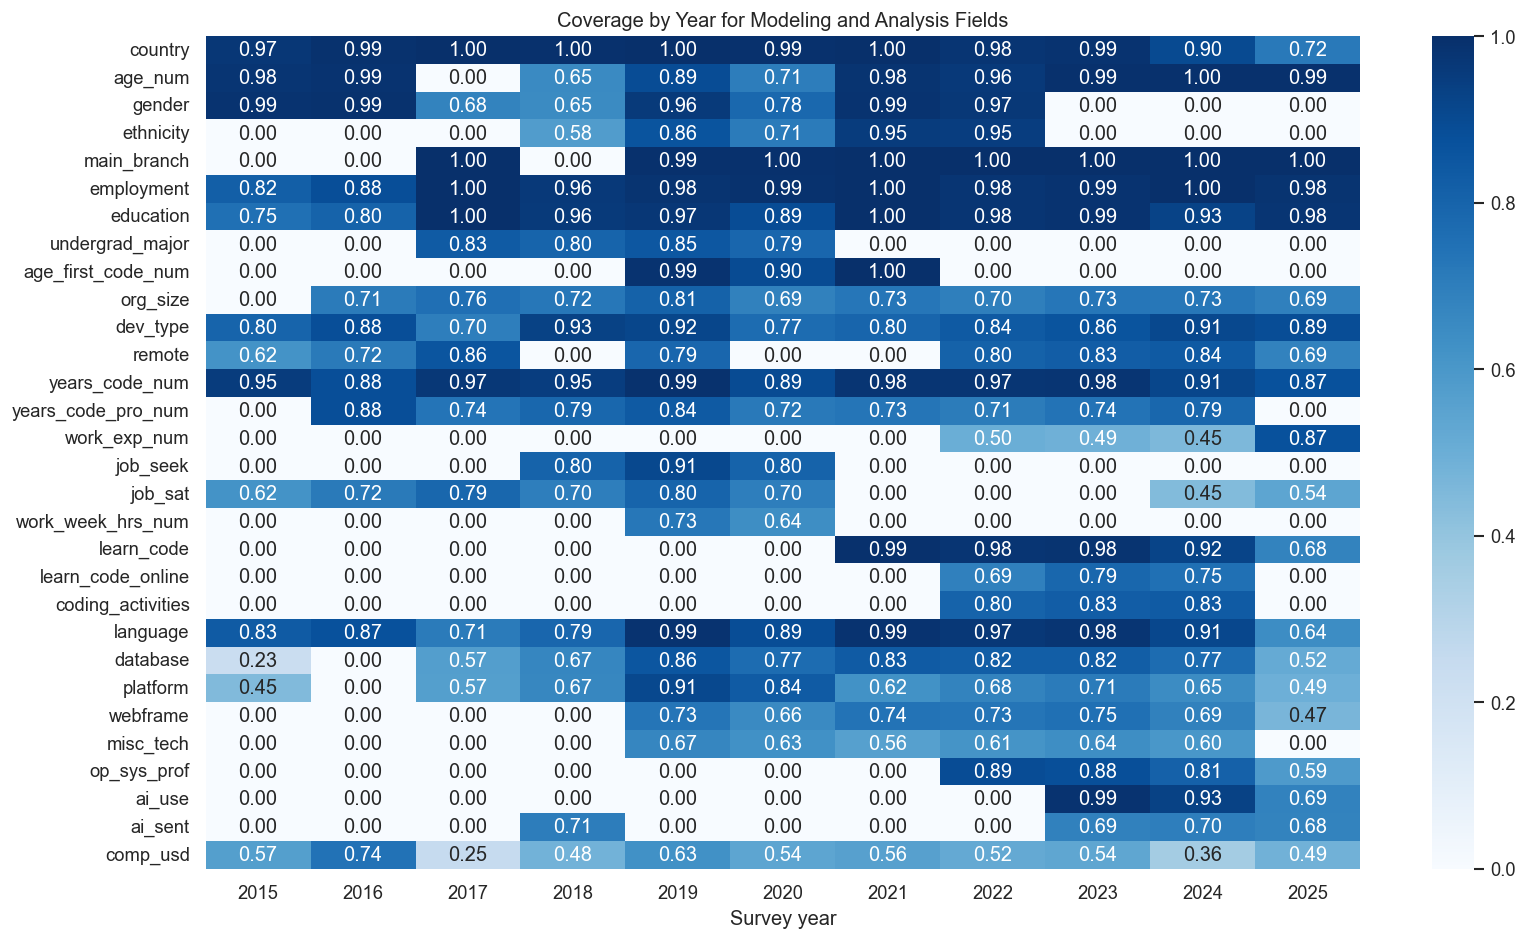

2015 derived multi-select coverage


education       75.3
language        83.3
database        23.1
platform        44.8
current_tech    84.7
Name: non_null_pct, dtype: float64

,education,language,database,platform,current_tech
12477,Bachelor's degree,Java;JavaScript,<NA>,<NA>,Java;JavaScript
11743,No formal education / other,C++;JavaScript;Python;SQL,<NA>,AngularJS,C++;JavaScript;Python;SQL;AngularJS
12829,Master's degree,JavaScript;PHP;SQL,<NA>,LAMP;Wordpress,JavaScript;PHP;SQL;LAMP;Wordpress
13064,No formal education / other,C;C++;Go;Java;JavaScript;Python;R;Ruby,MongoDB,Android;AngularJS;Arduino;Node.js,C;C++;Go;Java;JavaScript;Python;R;Ruby;MongoDB...
14442,<NA>,PHP;SQL,<NA>,Wordpress,PHP;SQL;Wordpress


In [5]:
clean = core_raw.copy()


# Don't want to type this for every Series with text fields I encounter
def lower_text(series):
    return series.fillna('').astype(str).str.lower().str.strip()


employment_text = lower_text(clean['employment'])
branch_text = lower_text(clean['main_branch'])
dev_text = lower_text(clean['dev_type'])
student_text = lower_text(clean['student'])


# Explicitly sets standard employment type groupins
employment_group = np.select(
    [
        employment_text.str.contains('self-employed|independent contractor|freelance|contractor'),
        employment_text.str.contains('part-time') & employment_text.str.contains('employed'),
        employment_text.str.contains('full-time') & employment_text.str.contains('employed'),
        employment_text.str.contains('not employed'),
        student_text.str.contains('yes|student') | employment_text.str.contains('student')
    ],
    ['Independent / contract', 'Employed part-time', 'Employed full-time', 'Not employed', 'Student'],
    default='Other'
)
clean['employment_group'] = pd.Series(employment_group, index=clean.index).where(clean['employment'].notna() | clean['student'].notna(), pd.NA)


# Explicitly flags whether someone is employed or not
clean['is_employed'] = (
    employment_text.str.contains('employed')
    | employment_text.str.contains('contractor')
    | employment_text.str.contains('freelance')
    | employment_text.str.contains('self-employed')
) & ~employment_text.str.contains('not employed')


# Explicitly sets if someone works in data field professionally
branch_prof = (
    branch_text.str.contains('developer by profession')
    | branch_text.eq('professional developer')
    | branch_text.eq('professional non-developer who sometimes writes code')
)
clean['is_professional'] = np.where(
    branch_text.ne(''),
    branch_prof,
    clean['is_employed'] & ~dev_text.str.contains('student')
)


# Data before 2019 behaves different, so this flags data inside and outside that window
clean['is_modern_window'] = clean['survey_year'] >= 2019


# Summary of available rows and percentage of respondents that are employed or professional per year
cohort_summary = clean.groupby('survey_year').agg(
    rows=('row_id', 'size'),
    employed_share=('is_employed', 'mean'),
    professional_share=('is_professional', 'mean')
)
display(cohort_summary.round(3))


# Define interesting fields and display percent of non-null values per year
coverage_fields = [
    'country',
    'age_num',
    'gender',
    'ethnicity',
    'main_branch',
    'employment',
    'education',
    'undergrad_major',
    'age_first_code_num',
    'org_size',
    'dev_type',
    'remote',
    'years_code_num',
    'years_code_pro_num',
    'work_exp_num',
    'job_seek',
    'job_sat',
    'work_week_hrs_num',
    'learn_code',
    'learn_code_online',
    'coding_activities',
    'language',
    'database',
    'platform',
    'webframe',
    'misc_tech',
    'op_sys_prof',
    'ai_use',
    'ai_sent',
    'comp_usd'
]
coverage = clean.groupby('survey_year')[coverage_fields].apply(lambda frame: frame.notna().mean())
display((coverage * 100).round(1))


# Heatmap showing percent of non-null values for each selected field across all years
plt.figure(figsize=(14, 8))
sns.heatmap(
    coverage.T,
    cmap='Blues',
    vmin=0,
    vmax=1,
    annot=True,
    fmt='.2f'
)
plt.title("Coverage by Year for Modeling and Analysis Fields")
plt.xlabel("Survey year")
plt.ylabel('')
plt.tight_layout()
plt.show()


# Shows non-null percent values in the fields created for 2015 and gives a sample of them
cols_2015 = ['education', 'language', 'database', 'platform', 'current_tech']
derived_2015 = clean.loc[clean['survey_year'] == 2015, cols_2015]
print("2015 derived multi-select coverage")
display((derived_2015.notna().mean() * 100).round(1).rename('non_null_pct'))
display(derived_2015.sample(5, random_state=42))

## Country, Region, Education, Org Size, and Remote

These were the highest value categorical fields from EDA because they directly affect trend and regional interpretation.

,country_clean_share,region_share
survey_year,,
2015,0.969,0.969
2016,0.991,0.991
2017,0.997,0.997
2018,0.995,0.995
2019,0.997,0.997
2020,0.993,0.993
2021,0.999,0.999
2022,0.979,0.979
2023,0.986,0.986


Countries still missing a region mapping


country_clean
Antarctica                    12
Netherlands Antilles           3
Bouvet Island                  2
Tadjikistan                    2
Polynesia (French)             2
Heard and McDonald Islands     1
Name: count, dtype: int64

,field,raw_levels,clean_levels
0,education,1022,10
1,org_size,27,6
2,remote,22,3


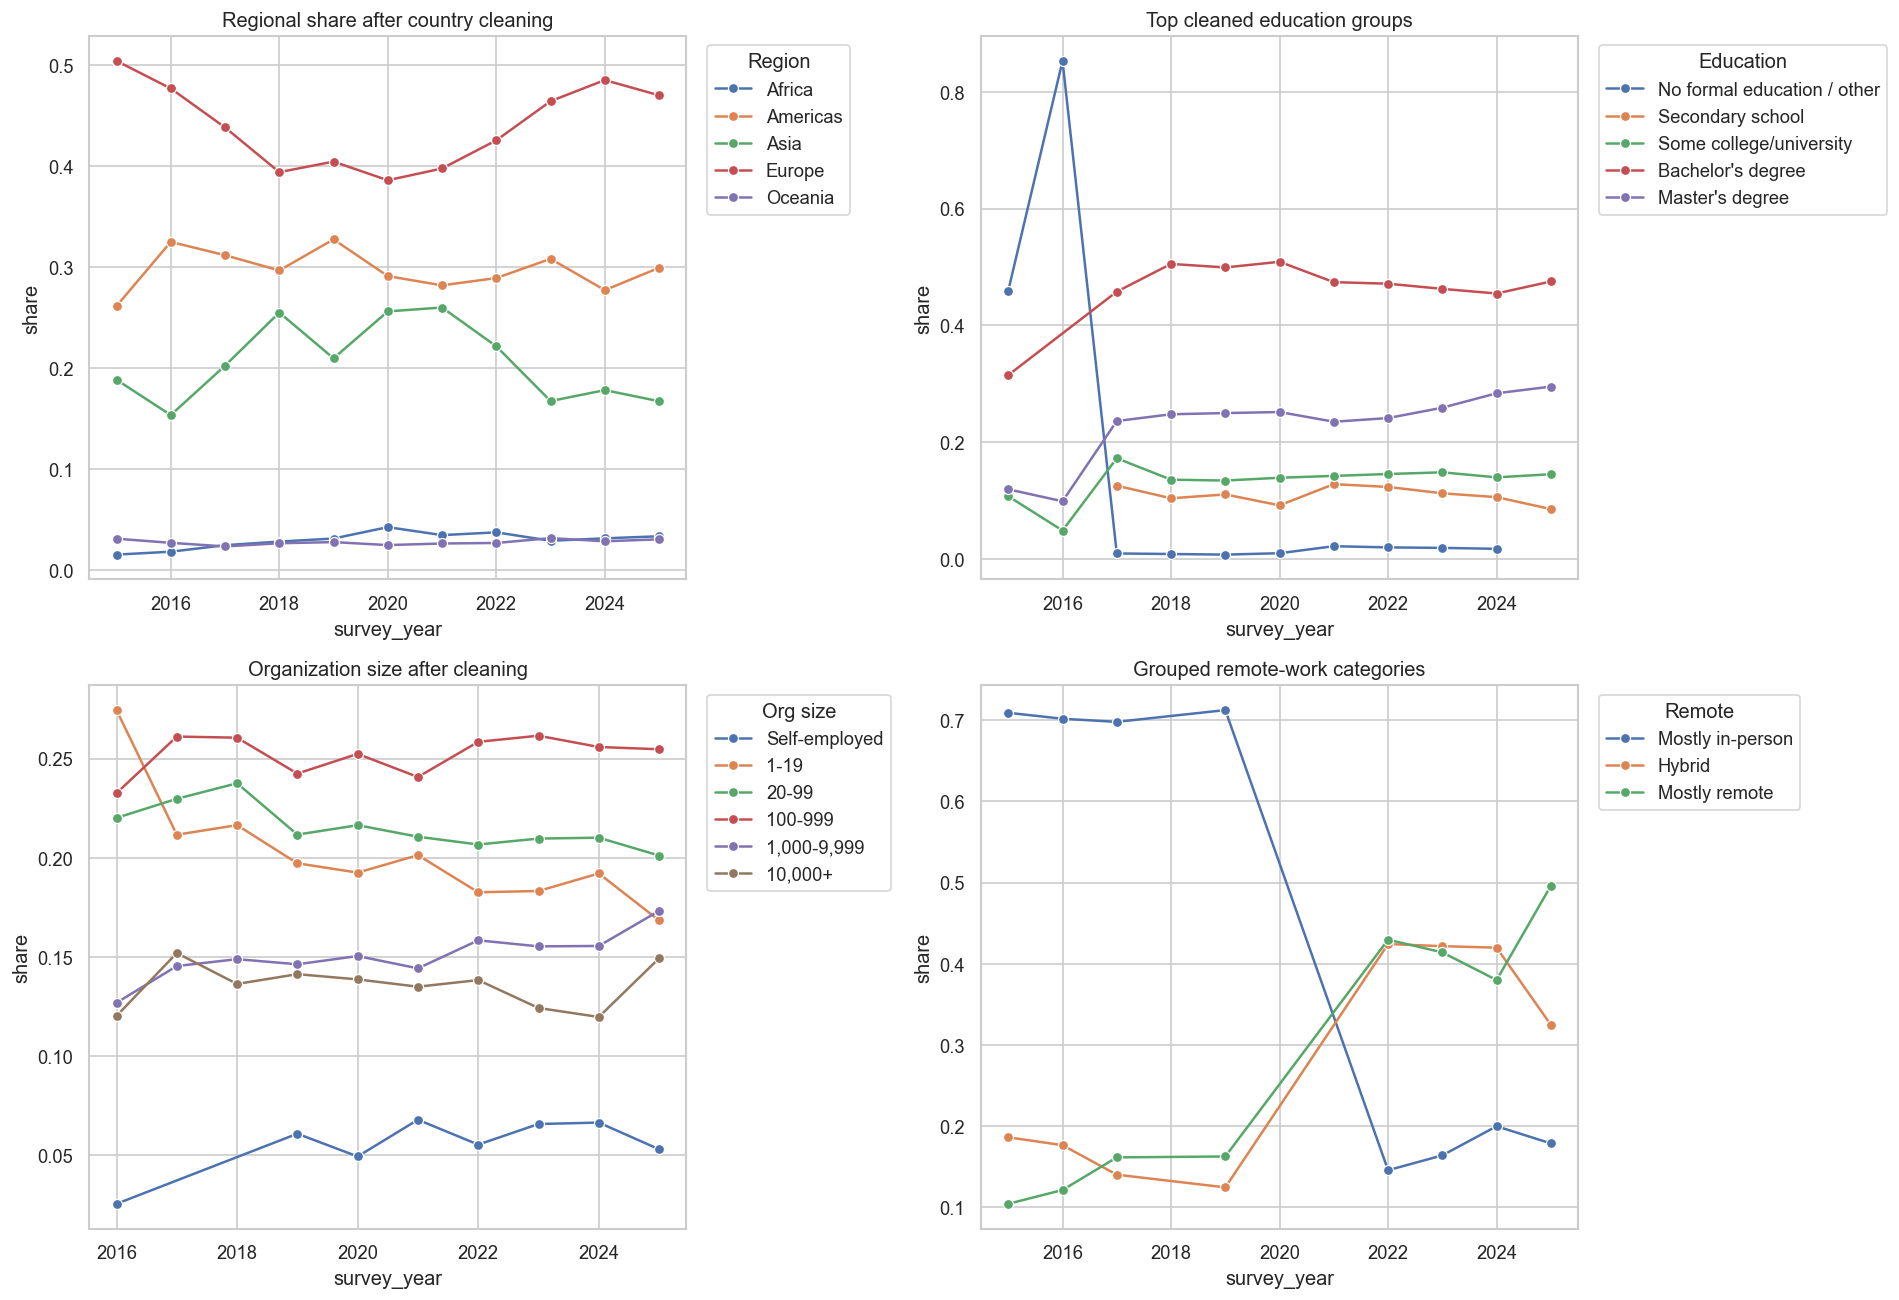

In [6]:
# Country responses that can't be mapped
COUNTRY_SPECIAL = {'Nomadic', 'Other Country (Not Listed Above)', 'I prefer not to say', 'Other (please specify)'}

# Country responses with weird or non-standard naming
COUNTRY_ALIAS = {
    'Venezuela, Bolivarian Republic of...': 'Venezuela',
    'Iran, Islamic Republic of...': 'Iran',
    'Viet Nam': 'Vietnam',
    'Republic of Korea': 'South Korea',
    'Korea South': 'South Korea',
    "Democratic People's Republic of Korea": 'North Korea',
    'Korea North': 'North Korea',
    'Hong Kong (S.A.R.)': 'Hong Kong',
    'Republic of Moldova': 'Moldova',
    'Moldavia': 'Moldova',
    'Bosnia Herzegovina': 'Bosnia and Herzegovina',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'The former Yugoslav Republic of Macedonia': 'North Macedonia',
    'Republic of North Macedonia': 'North Macedonia',
    'Macedonia': 'North Macedonia',
    "Lao People's Democratic Republic": 'Laos',
    'Syrian Arab Republic': 'Syria',
    'United Republic of Tanzania': 'Tanzania',
    'Libyan Arab Jamahiriya': 'Libya',
    'Myanmar, {Burma}': 'Myanmar',
    'Ireland {Republic}': 'Ireland',
    'Azerbaidjan': 'Azerbaijan',
    'Antigua & Deps': 'Antigua and Barbuda',
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'Micronesia, Federated States of...': 'Micronesia',
    'Virgin Islands (USA)': 'United States Virgin Islands',
    'Reunion (French)': 'Reunion',
    'New Caledonia (French)': 'New Caledonia'
}

REGION_ALLOWED = {'Africa', 'Americas', 'Asia', 'Europe', 'Oceania'}

# Ordering for plot labels so they make sense
EDUCATION_ORDER = [
    'No formal education / other',
    'Primary/elementary school',
    'Secondary school',
    'Some college/university',
    'Associate degree',
    "Bachelor's degree",
    "Master's degree",
    'Professional degree',
    'Doctoral degree'
]
ORG_SIZE_ORDER = ['Self-employed', '1-19', '20-99', '100-999', '1,000-9,999', '10,000+']
REMOTE_ORDER = ['Mostly in-person', 'Hybrid', 'Mostly remote']


# Uses the country converter package to capture more countries and map to a region
cc = coco.CountryConverter()
def convert_one_country(name, target):
    value = cc.convert(names=name, to=target, not_found=None)
    if isinstance(value, (list, tuple, np.ndarray)):
        value = value[0] if len(value) else pd.NA
    if value in {'not found', 'not found in regex', '', 'Other'}:
        return pd.NA
    return value


# Builds a fully cleaned DataFrame that maps countries to the region they are located in
def build_country_lookup(series):
    lookup = pd.DataFrame({'country': sorted(series.dropna().astype(str).str.strip().unique())})
    lookup['country_input'] = lookup['country'].replace(COUNTRY_ALIAS)
    lookup.loc[lookup['country'].isin(COUNTRY_SPECIAL), 'country_input'] = pd.NA

    lookup['country_clean'] = pd.NA
    lookup['region'] = pd.NA

    valid = lookup['country_input'].notna()
    lookup.loc[valid, 'country_clean'] = lookup.loc[valid, 'country_input'].map(lambda name: convert_one_country(name, 'name_short'))
    lookup.loc[valid, 'region'] = lookup.loc[valid, 'country_input'].map(lambda name: convert_one_country(name, 'continent'))

    lookup['country_clean'] = lookup['country_clean'].replace(['not found', 'not found in regex', '', 'Other'], pd.NA)
    lookup['region'] = lookup['region'].replace({'America': 'Americas', 'Antarctica': pd.NA, 'not found': pd.NA, 'not found in regex': pd.NA, '': pd.NA, 'Other': pd.NA})
    lookup['region'] = lookup['region'].where(lookup['region'].isin(REGION_ALLOWED), pd.NA)
    return lookup[['country', 'country_clean', 'region']]


# Education doesn't have standardized values across the years, this cleans inputs and groups them into appropriate categories
def clean_education(value):
    if pd.isna(value):
        return pd.NA
    text = re.sub(r'\s*\([^)]*\)', '', str(value).strip())
    lower = re.sub(r'master.?s', "master's", re.sub(r'bachelor.?s', "bachelor's", text.lower()))
    if 'prefer not' in lower:
        return pd.NA
    if 'never completed any formal education' in lower or 'self-taught' in lower or 'something else' in lower or 'no formal' in lower:
        return 'No formal education / other'
    if 'primary' in lower or 'elementary' in lower:
        return 'Primary/elementary school'
    if 'secondary school' in lower:
        return 'Secondary school'
    if 'some college' in lower or 'some university' in lower:
        return 'Some college/university'
    if 'associate degree' in lower:
        return 'Associate degree'
    if 'bachelor' in lower:
        return "Bachelor's degree"
    if 'master' in lower:
        return "Master's degree"
    if 'professional degree' in lower:
        return 'Professional degree'
    if 'doctoral degree' in lower or 'ph.d' in lower or 'ed.d' in lower:
        return 'Doctoral degree'
    return 'Other / ungrouped'


# Organization size also isn't standardized, with overlapping values and different text formatting. This fixes that
def clean_org_size(value):
    if pd.isna(value):
        return pd.NA
    lower = str(value).strip().lower()
    if any(term in lower for term in ["don't know", 'don?t know', 'not sure', 'prefer not']):
        return pd.NA
    if 'just me' in lower or 'not part of a company' in lower:
        return 'Self-employed'
    if any(term in lower for term in [
        '1-4 employees',
        '2 to 9 employees',
        '2-9 employees',
        '5-9 employees',
        'fewer than 10 employees',
        '10 to 19 employees',
        '10-19 employees',
        'less than 20 employees'
        ]
    ):
        return '1-19'
    if '20 to 99 employees' in lower or '20-99 employees' in lower:
        return '20-99'
    if any(term in lower for term in ['100 to 499 employees', '100-499 employees', '500 to 999 employees', '500-999 employees']):
        return '100-999'
    if any(term in lower for term in ['1,000 to 4,999 employees', '1,000-4,999 employees', '5,000 to 9,999 employees', '5,000-9,999 employees']):
        return '1,000-9,999'
    if '10,000 or more employees' in lower or '10,000+ employees' in lower:
        return '10,000+'
    return pd.NA


# Remote has many values that can vaguely describe the same thing, this creates three neat groups
def group_remote(value):
    if pd.isna(value):
        return pd.NA
    mostly_in_person = {
        'In-person',
        'Full in-person',
        'Never',
        'Less than once per month / Never',
        'I rarely work remote',
        'I rarely work remotely',
        'A few days each month'
    }
    hybrid = {
        'Less than half the time, but at least one day each week',
        'About half the time',
        'Part-time remote',
        'Part-time Remote',
        'Hybrid (some remote, leans heavy to in-person)',
        'Hybrid (some remote, some in-person)',
        'Your choice (very flexible, you can come in when you want or just as needed)'
    }
    mostly_remote = {
        'More than half, but not all, the time',
        'Hybrid (some in-person, leans heavy to flexibility)',
        'Fully remote',
        'Full-time remote',
        'Full-time Remote',
        "All or almost all the time (I'm full-time remote)",
        'Remote'
    }
    if value in mostly_in_person:
        return 'Mostly in-person'
    if value in hybrid:
        return 'Hybrid'
    if value in mostly_remote:
        return 'Mostly remote'
    return pd.NA


# Meat of the cell, calculates percent makeup of values per column and orders them as I set
def top_share(frame, column, top_n=5, order=None):
    counts = frame.dropna(subset=[column]).groupby(['survey_year', column]).size().rename('count').reset_index()
    top_values = counts[column].drop_duplicates().tolist() if top_n is None else counts.groupby(column)['count'].sum().nlargest(top_n).index.tolist()
    if order is not None:
        rank = {value: i for i, value in enumerate(order)}
        top_values = sorted(top_values, key=lambda value: rank.get(value, len(rank)))
    counts = counts.loc[counts[column].isin(top_values)].copy()
    counts['share'] = counts['count'] / counts.groupby('survey_year')['count'].transform('sum')
    return counts, top_values


# Sets up a clean DataFrame of the grouped and standardized features
country_lookup = build_country_lookup(clean['country'])
clean = clean.drop(columns=['country_clean', 'region'], errors='ignore').merge(country_lookup, on='country', how='left')
clean['education_clean'] = clean['education'].map(clean_education)
clean['org_size_clean'] = clean['org_size'].map(clean_org_size)
clean['remote_group'] = clean['remote'].map(group_remote)


# Get the percent of responses per year that were able to have their country name properly cleaned and mapped
region_quality = clean.groupby('survey_year').agg(country_clean_share=('country_clean', lambda s: s.notna().mean()), region_share=('region', lambda s: s.notna().mean()))
display(region_quality.round(3))

# Get the countries not mapped to a region by cleaning setup
print("Countries still missing a region mapping")
display(clean.loc[clean['country_clean'].notna() & clean['region'].isna(), 'country_clean'].value_counts().head(20))

# Show the before and after level count for the features
display(pd.DataFrame({
    'field': ['education', 'org_size', 'remote'],
    'raw_levels': [clean['education'].dropna().nunique(), clean['org_size'].dropna().nunique(), clean['remote'].dropna().nunique()],
    'clean_levels': [clean['education_clean'].dropna().nunique(), clean['org_size_clean'].dropna().nunique(), clean['remote_group'].dropna().nunique()]
}))


# Build top share percent lists for each of the features
region_counts = clean.dropna(subset=['region']).groupby(['survey_year', 'region']).size().rename('count').reset_index()
region_counts['share'] = region_counts['count'] / region_counts.groupby('survey_year')['count'].transform('sum')
education_share, education_order = top_share(clean, 'education_clean', top_n=5, order=EDUCATION_ORDER)
org_share, org_order = top_share(clean, 'org_size_clean', top_n=None, order=ORG_SIZE_ORDER)
remote_share, remote_order = top_share(clean, 'remote_group', top_n=None, order=REMOTE_ORDER)


# Line plots for each of the cleaned/grouped features showing trends across the years
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.lineplot(data=region_counts, x='survey_year', y='share', hue='region', marker='o', ax=axes[0, 0])
axes[0, 0].set_title("Regional share after country cleaning")
axes[0, 0].legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=education_share, x='survey_year', y='share', hue='education_clean', hue_order=education_order, marker='o', ax=axes[0, 1])
axes[0, 1].set_title("Top cleaned education groups")
axes[0, 1].legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=org_share, x='survey_year', y='share', hue='org_size_clean', hue_order=org_order, marker='o', ax=axes[1, 0])
axes[1, 0].set_title("Organization size after cleaning")
axes[1, 0].legend(title='Org size', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=remote_share, x='survey_year', y='share', hue='remote_group', hue_order=remote_order, marker='o', ax=axes[1, 1])
axes[1, 1].set_title("Grouped remote-work categories")
axes[1, 1].legend(title='Remote', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Numeric Cleanup and Compensation Sample

Removes obviously bad numeric values, builds a cross-year professional experience field, and defines a compensation analysis window.

,age_available,pro_exp_available,valid_comp_share,core_model_share,tech_rich_share,ai_era_share
survey_year,,,,,,
2015,0.977,0.000,0.570,0.000,0.000,0.000
2016,0.988,0.884,0.745,0.000,0.000,0.000
2017,0.000,0.728,0.245,0.000,0.000,0.000
2018,0.653,0.782,0.467,0.000,0.000,0.000
2019,0.890,0.825,0.609,0.551,0.000,0.000
2020,0.705,0.712,0.527,0.479,0.000,0.000
2021,0.981,0.726,0.551,0.503,0.503,0.000
2022,0.961,0.737,0.503,0.463,0.463,0.000
2023,0.995,0.765,0.530,0.490,0.490,0.490


,years_code_gt_50,years_code_pro_gt_years_code,work_exp_gt_50,age_first_code_outside_range,work_week_hrs_outside_range,comp_outside_range
survey_year,,,,,,
2015,0,0,0,0,0,0
2016,0,0,0,0,0,0
2017,0,457,0,0,0,318
2018,0,629,0,0,0,1563
2019,0,969,0,33,519,1689
2020,0,476,0,22,185,760
2021,0,647,0,0,0,831
2022,0,536,0,0,0,1202
2023,0,682,0,0,0,744


Feature coverage inside the 2019+ compensation sample


country_clean                     99.9
region                            99.9
employment_group                 100.0
age_mid                           97.6
education_clean                   99.5
org_size_clean                    97.8
remote_group                      68.0
professional_experience_years     99.1
language_count                    98.8
database_count                    87.8
platform_count                    81.6
dev_type                          99.7
Name: non_null_pct, dtype: float64

,survey_year,region,n,median_comp
0,2019,Africa,1124,13512.0
1,2019,Americas,17299,90000.0
2,2019,Asia,7815,14484.0
3,2019,Europe,21247,50184.0
4,2019,Oceania,1427,76156.0
5,2020,Africa,786,14142.0
6,2020,Americas,10284,90000.0
7,2020,Asia,5371,14256.0
8,2020,Europe,13576,50806.0
9,2020,Oceania,873,73491.0


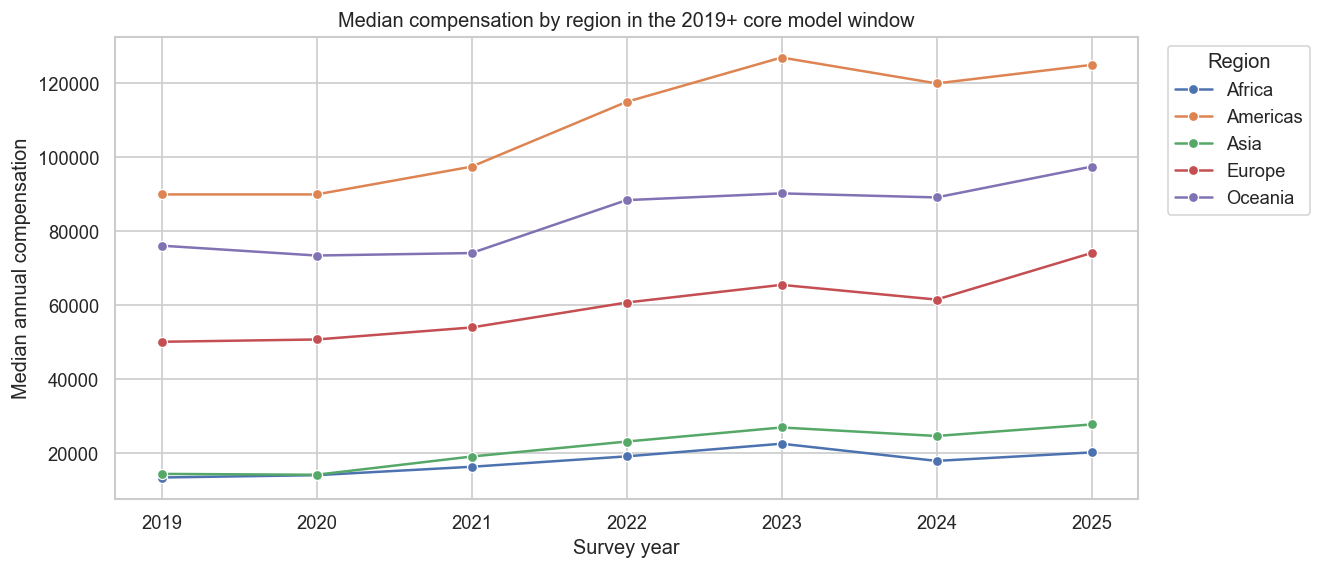

In [7]:
# Sets parameters for what values should be considered valid for the given fields. There's a lot of nonsense in there.
clean['age_mid'] = clean['age_num'].where(clean['age_num'].between(10, 90))
clean['age_first_code_clean'] = clean['age_first_code_num'].where(clean['age_first_code_num'].between(5, 70))
clean['years_code_clean'] = clean['years_code_num'].where(clean['years_code_num'].between(0, 50))
clean['years_code_pro_clean'] = clean['years_code_pro_num'].where(clean['years_code_pro_num'].between(0, 50))
clean['work_exp_clean'] = clean['work_exp_num'].where(clean['work_exp_num'].between(0, 50))
clean['work_week_hrs_clean'] = clean['work_week_hrs_num'].where(clean['work_week_hrs_num'].between(1, 100))
clean.loc[(clean['years_code_pro_clean'] > clean['years_code_clean']) & clean['years_code_clean'].notna(), 'years_code_pro_clean'] = np.nan
clean['professional_experience_years'] = clean['years_code_pro_clean'].combine_first(clean['work_exp_clean'])
clean['comp_usd_clean'] = clean['comp_usd'].where(clean['comp_usd'].between(1000, 1_000_000))
clean['log_comp_usd_clean'] = np.log(clean['comp_usd_clean'])
clean['age_group'] = pd.cut(clean['age_mid'], bins=[10, 25, 35, 45, 55, 100], labels=['Under 25', '25-34', '35-44', '45-54', '55+'], right=False)
clean['experience_bin'] = pd.cut(clean['professional_experience_years'], bins=[0, 2, 5, 10, 20, 60], labels=['0-2', '3-5', '6-10', '11-20', '21+'], include_lowest=True)


# Gets counts of levels for fields with multiple responses
def multi_count(series):
    counts = series.fillna('').astype(str).str.split(';').map(lambda items: sum(item.strip() not in {'', 'nan'} for item in items))
    return counts.where(series.notna(), np.nan)


clean['language_count'] = multi_count(clean['language'])
clean['database_count'] = multi_count(clean['database'])
clean['platform_count'] = multi_count(clean['platform'])
clean['webframe_count'] = multi_count(clean['webframe'])
clean['misc_tech_count'] = multi_count(clean['misc_tech'])

# Defines selection of features that note if a response is suitable for compensation analysis
clean['is_comp_analysis_sample'] = (
    clean['is_professional']
    & clean['comp_usd_clean'].notna()
    & clean['employment_group'].ne('Not employed')
)

# Define regions of compensation models based on the year
clean['is_comp_model_core'] = (clean['survey_year'] >= 2019) & clean['is_comp_analysis_sample']
clean['is_comp_model_tech_rich'] = (clean['survey_year'] >= 2021) & clean['is_comp_analysis_sample']
clean['is_comp_model_ai_era'] = (clean['survey_year'] >= 2023) & clean['is_comp_analysis_sample']
clean['is_comp_model_extended'] = clean['is_comp_model_tech_rich']
clean['is_comp_model_sample'] = clean['is_comp_model_core']

# Show coverage of major defined features per year
sample_summary = clean.groupby('survey_year').agg(
    age_available=('age_mid', lambda s: s.notna().mean()),
    pro_exp_available=('professional_experience_years', lambda s: s.notna().mean()),
    valid_comp_share=('comp_usd_clean', lambda s: s.notna().mean()),
    core_model_share=('is_comp_model_core', 'mean'),
    tech_rich_share=('is_comp_model_tech_rich', 'mean'),
    ai_era_share=('is_comp_model_ai_era', 'mean')
)
display(sample_summary.round(3))


# Show how many values for our major feaures are outside the ranges we want
quality_checks = pd.DataFrame({
    'years_code_gt_50': clean.groupby('survey_year')['years_code_num'].apply(lambda s: (s > 50).sum()),
    'years_code_pro_gt_years_code': clean.groupby('survey_year').apply(lambda frame: (
        (frame['years_code_pro_num'] > frame['years_code_num'])
        & frame['years_code_num'].notna()
        & frame['years_code_pro_num'].notna()
    ).sum()),
    'work_exp_gt_50': clean.groupby('survey_year')['work_exp_num'].apply(lambda s: (s > 50).sum()),
    'age_first_code_outside_range': clean.groupby('survey_year').apply(lambda frame: (
        frame['age_first_code_num'].notna()
        & ~frame['age_first_code_num'].between(5, 70)
    ).sum()),
    'work_week_hrs_outside_range': clean.groupby('survey_year').apply(lambda frame: (
        frame['work_week_hrs_num'].notna()
        & ~frame['work_week_hrs_num'].between(1, 100)
    ).sum()),
    'comp_outside_range': clean.groupby('survey_year').apply(lambda frame: (
        frame['comp_usd'].notna()
        & ~frame['comp_usd'].between(1000, 1_000_000)
    ).sum())
})
display(quality_checks)


# Coverage of desired feature in just the 2019+ window
print("Feature coverage inside the 2019+ compensation sample")
core_feature_cols = [
    'country_clean',
    'region',
    'employment_group',
    'age_mid',
    'education_clean',
    'org_size_clean',
    'remote_group',
    'professional_experience_years',
    'language_count',
    'database_count',
    'platform_count',
    'dev_type'
]
display((clean.loc[clean['is_comp_model_core'], core_feature_cols].notna().mean() * 100).round(1).rename('non_null_pct'))


# Cleaned median compensation by region per year
comp_region = clean.loc[clean['is_comp_model_core']].groupby(['survey_year', 'region']).agg(n=('row_id', 'size'), median_comp=('comp_usd_clean', 'median')).reset_index()
comp_region = comp_region.loc[comp_region['n'] >= 300]
display(comp_region.head(15))


# Visual of cleaned median compensation by region trendlines
plt.figure(figsize=(11, 5))
sns.lineplot(data=comp_region, x='survey_year', y='median_comp', hue='region', marker='o')
plt.title("Median compensation by region in the 2019+ core model window")
plt.xlabel("Survey year")
plt.ylabel("Median annual compensation")
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


## Compensation Modeling Plan

The compensation question should use a simple baseline first, then linear models, then a nonlinear benchmark. This notebook now keeps a broad `2019+` core window and a narrower `2022+` extended window for remote, learning, and AI features.

In [8]:
# Viable plans for modeling compensation
model_plan = pd.DataFrame([
    {
        "model": "Year-region median benchmark",
        "window": "2019+ core",
        "split": "Train 2019-2023, validate 2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Sets the minimum bar and checks how much geography plus year explain on their own",
    },
    {
        "model": "Ridge regression",
        "window": "2019+ core",
        "split": "Train 2019-2023, validate 2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Gives stable coefficient estimates for experience, education, employment, org size, role, and tech breadth",
    },
    {
        "model": "ElasticNet regression",
        "window": "2019+ core",
        "split": "Train 2019-2023, validate 2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Useful if one-hot role and geography features get wide and we want sparse selection",
    },
    {
        "model": "ExtraTreesRegressor",
        "window": "2019+ core",
        "split": "Train 2019-2023, validate 2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Captures nonlinearity and interactions without adding more package complexity",
    },
    {
        "model": "Tech-rich ExtraTreesRegressor",
        "window": "2021+ tech-rich",
        "split": "Train 2021-2023, validate 2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Adds learn-code, web framework, and misc tech fields once those questions become broadly available",
    },
    {
        "model": "AI-era ExtraTreesRegressor",
        "window": "2023+ AI-era",
        "split": "Train 2023-2024, test 2025",
        "metrics": "MedAE and RMSE on log pay",
        "why": "Tests whether AI usage and sentiment add signal in the latest survey waves",
    },
])
display(model_plan)


# Return whether a feature is explicitly tracked for each year
def mapped_years(field):
    years = [str(year) for year, info in YEAR_INFO.items() if info.get(field) is not None]
    return ", ".join(years) if years else "derived only"


# Audit all major fields to show where they exist and if they can be used
field_audit = pd.DataFrame([
    {
        "field": "country",
        "tier": "Core",
        "years_mapped": mapped_years("country"),
        "note": "Feeds country_clean and region",
    },
    {
        "field": "employment",
        "tier": "Core",
        "years_mapped": mapped_years("employment"),
        "note": "Feeds employment_group and compensation sample restrictions",
    },
    {
        "field": "education",
        "tier": "Core",
        "years_mapped": mapped_years("education"),
        "note": "Feeds education_clean",
    },
    {
        "field": "org_size",
        "tier": "Core",
        "years_mapped": mapped_years("org_size"),
        "note": "Feeds org_size_clean",
    },
    {
        "field": "dev_type",
        "tier": "Core",
        "years_mapped": mapped_years("dev_type"),
        "note": "Feeds role-family flags later in the notebook",
    },
    {
        "field": "years_code / years_code_pro / work_exp",
        "tier": "Core",
        "years_mapped": "2015-2025",
        "note": "Feeds professional_experience_years",
    },
    {
        "field": "language / database / platform",
        "tier": "Core",
        "years_mapped": "2015-2025",
        "note": "Feeds tech breadth counts",
    },
    {
        "field": "webframe",
        "tier": "Tech-rich",
        "years_mapped": mapped_years("webframe"),
        "note": "Added to 2019-2020 this pass so later framework features are not under-counted",
    },
    {
        "field": "misc_tech",
        "tier": "Tech-rich",
        "years_mapped": mapped_years("misc_tech"),
        "note": "Added to 2019-2020 this pass for broader tooling coverage",
    },
    {
        "field": "learn_code",
        "tier": "Tech-rich",
        "years_mapped": mapped_years("learn_code"),
        "note": "Useful for later-year learning-pattern analysis",
    },
    {
        "field": "learn_code_online",
        "tier": "AI-era / later-year",
        "years_mapped": mapped_years("learn_code_online"),
        "note": "Patchier but useful for later-year models",
    },
    {
        "field": "coding_activities",
        "tier": "AI-era / later-year",
        "years_mapped": mapped_years("coding_activities"),
        "note": "Good for hobby versus work coding splits",
    },
    {
        "field": "remote",
        "tier": "AI-era / later-year",
        "years_mapped": mapped_years("remote"),
        "note": "Useful where the survey actually asked it",
    },
    {
        "field": "gender",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("gender"),
        "note": "Present through 2022, absent again in 2023+",
    },
    {
        "field": "ethnicity",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("ethnicity"),
        "note": "2018 added this pass, then available through 2022 only",
    },
    {
        "field": "undergrad_major",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("undergrad_major"),
        "note": "Useful side model feature, not stable enough for the main window",
    },
    {
        "field": "age_first_code",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("age_first_code"),
        "note": "Useful for narrower experience-side models",
    },
    {
        "field": "job_seek",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("job_seek"),
        "note": "Good for a side model, but too patchy for the core baseline",
    },
    {
        "field": "work_week_hrs",
        "tier": "Restricted-window",
        "years_mapped": mapped_years("work_week_hrs"),
        "note": "Only really usable in 2019-2020",
    },
    {
        "field": "ai_use / ai_sent",
        "tier": "AI-era",
        "years_mapped": "2023-2025",
        "note": "Keep out of the core model and test only in the AI-era window",
    },
    {
        "field": "job_sat",
        "tier": "Separate target",
        "years_mapped": mapped_years("job_sat"),
        "note": "Keep in the clean baseline, but do not use it as a compensation feature",
    },
])
display(field_audit)


# Show coverage of major features in the 2019+ window
print("Core feature coverage in the 2019+ compensation model window")
core_features = [
    "country_clean",
    "region",
    "employment_group",
    "age_mid",
    "education_clean",
    "org_size_clean",
    "professional_experience_years",
    "language_count",
    "database_count",
    "platform_count",
    "dev_type",
]
display(
    (clean.loc[clean["is_comp_model_core"], core_features].notna().mean() * 100)
    .round(1)
    .rename("non_null_pct")
)


# Show coverage of major features in the 2021+ window
print("Tech-rich feature coverage in the 2021+ compensation model window")
tech_features = [
    "country_clean",
    "region",
    "employment_group",
    "age_mid",
    "education_clean",
    "org_size_clean",
    "professional_experience_years",
    "learn_code",
    "webframe",
    "misc_tech",
    "language_count",
    "database_count",
    "platform_count",
    "webframe_count",
    "misc_tech_count",
]
display(
    (clean.loc[clean["is_comp_model_tech_rich"], tech_features].notna().mean() * 100)
    .round(1)
    .rename("non_null_pct")
)


# Show coverage of major featurees in the 2023+ window
print("AI-era feature coverage in the 2023+ compensation model window")
ai_features = [
    "country_clean",
    "region",
    "employment_group",
    "age_mid",
    "education_clean",
    "org_size_clean",
    "remote_group",
    "professional_experience_years",
    "learn_code",
    "learn_code_online",
    "coding_activities",
    "webframe",
    "misc_tech",
    "op_sys_prof",
    "ai_use",
    "ai_sent",
    "language_count",
    "database_count",
    "platform_count",
    "webframe_count",
    "misc_tech_count",
]
display(
    (clean.loc[clean["is_comp_model_ai_era"], ai_features].notna().mean() * 100)
    .round(1)
    .rename("non_null_pct")
)


# Show coverage of features that have a restricted set of years they appear in
print("Restricted-window fields to test only in side models")
restricted_features = [
    "gender",
    "ethnicity",
    "undergrad_major",
    "age_first_code_clean",
    "job_seek",
    "work_week_hrs_clean",
]
restricted_coverage = (
    clean.loc[clean["is_comp_analysis_sample"]]
    .groupby("survey_year")[restricted_features]
    .apply(lambda frame: frame.notna().mean())
)
display((restricted_coverage * 100).round(1))


# Show share of each employment level in the 2019+ window
print("Employment mix inside the 2019+ compensation sample")
core_employment = (
    clean.loc[clean["is_comp_model_core"], "employment_group"]
    .fillna("Missing")
    .value_counts(normalize=True)
    .rename("share")
)
display((core_employment * 100).round(1).to_frame())


# Recommendations for each potential window to use for modeling compensation
cleaning_review = pd.DataFrame([
    {
        "decision": "Use 2019+ as the main compensation window",
        "status": "Keep",
        "note": "This is still the best balance of coverage, modern schema, and sample size",
    },
    {
        "decision": "Use 2021+ for tech-rich side models",
        "status": "Keep",
        "note": "This is where learn-code, webframe, and misc-tech fields become broadly usable",
    },
    {
        "decision": "Use 2023+ for AI-side models",
        "status": "Keep",
        "note": "This avoids backfilling AI concepts into years that never asked them",
    },
    {
        "decision": "Trim compensation outside 1,000 to 1,000,000 USD",
        "status": "Keep with caution",
        "note": "Reasonable for early modeling, but we should revisit if very-high-earner sensitivity matters",
    },
    {
        "decision": "Drop respondents explicitly marked not employed from compensation samples",
        "status": "Keep",
        "note": "This is a sensible restriction for a current-compensation target",
    },
    {
        "decision": "Keep job satisfaction in the clean baseline but not as a compensation feature",
        "status": "Keep",
        "note": "Useful later as its own target, but too close conceptually to use as a predictor here",
    },
    {
        "decision": "Run a year-by-year methodology audit before final modeling",
        "status": "Pending",
        "note": "Still needed to fully defend comparability and sample restrictions",
    },
])
display(cleaning_review)

,model,window,split,metrics,why
0,Year-region median benchmark,2019+ core,"Train 2019-2023, validate 2024, test 2025",MedAE and RMSE on log pay,Sets the minimum bar and checks how much geogr...
1,Ridge regression,2019+ core,"Train 2019-2023, validate 2024, test 2025",MedAE and RMSE on log pay,Gives stable coefficient estimates for experie...
2,ElasticNet regression,2019+ core,"Train 2019-2023, validate 2024, test 2025",MedAE and RMSE on log pay,Useful if one-hot role and geography features ...
3,ExtraTreesRegressor,2019+ core,"Train 2019-2023, validate 2024, test 2025",MedAE and RMSE on log pay,Captures nonlinearity and interactions without...
4,Tech-rich ExtraTreesRegressor,2021+ tech-rich,"Train 2021-2023, validate 2024, test 2025",MedAE and RMSE on log pay,"Adds learn-code, web framework, and misc tech ..."
5,AI-era ExtraTreesRegressor,2023+ AI-era,"Train 2023-2024, test 2025",MedAE and RMSE on log pay,Tests whether AI usage and sentiment add signa...


,field,tier,years_mapped,note
0,country,Core,"2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022...",Feeds country_clean and region
1,employment,Core,"2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022...",Feeds employment_group and compensation sample...
2,education,Core,"2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023...",Feeds education_clean
3,org_size,Core,"2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023...",Feeds org_size_clean
4,dev_type,Core,"2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022...",Feeds role-family flags later in the notebook
5,years_code / years_code_pro / work_exp,Core,2015-2025,Feeds professional_experience_years
6,language / database / platform,Core,2015-2025,Feeds tech breadth counts
7,webframe,Tech-rich,"2019, 2020, 2021, 2022, 2023, 2024, 2025",Added to 2019-2020 this pass so later framewor...
8,misc_tech,Tech-rich,"2019, 2020, 2021, 2022, 2023, 2024",Added to 2019-2020 this pass for broader tooli...
9,learn_code,Tech-rich,"2021, 2022, 2023, 2024, 2025",Useful for later-year learning-pattern analysis


Core feature coverage in the 2019+ compensation model window


country_clean                     99.9
region                            99.9
employment_group                 100.0
age_mid                           97.6
education_clean                   99.5
org_size_clean                    97.8
professional_experience_years     99.1
language_count                    98.8
database_count                    87.8
platform_count                    81.6
dev_type                          99.7
Name: non_null_pct, dtype: float64

Tech-rich feature coverage in the 2021+ compensation model window


...

Restricted-window fields to test only in side models


,gender,ethnicity,undergrad_major,age_first_code_clean,job_seek,work_week_hrs_clean
survey_year,,,,,,
2015,99.7,0.0,0.0,0.0,0.0,0.0
2016,99.7,0.0,0.0,0.0,0.0,0.0
2017,91.1,0.0,92.9,0.0,0.0,0.0
2018,93.8,86.9,91.7,0.0,100.0,0.0
2019,98.4,91.6,91.9,99.8,100.0,98.3
2020,92.8,87.0,92.9,99.7,97.3,96.5
2021,99.7,98.1,0.0,100.0,0.0,0.0
2022,99.7,98.8,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0,0.0,0.0


Employment mix inside the 2019+ compensation sample


,share
employment_group,
Employed full-time,77.7
Independent / contract,12.1
Other,7.2
Employed part-time,2.8
Student,0.1
Missing,0.0


,decision,status,note
0,Use 2019+ as the main compensation window,Keep,"This is still the best balance of coverage, mo..."
1,Use 2021+ for tech-rich side models,Keep,"This is where learn-code, webframe, and misc-t..."
2,Use 2023+ for AI-side models,Keep,This avoids backfilling AI concepts into years...
3,"Trim compensation outside 1,000 to 1,000,000 USD",Keep with caution,"Reasonable for early modeling, but we should r..."
4,Drop respondents explicitly marked not employe...,Keep,This is a sensible restriction for a current-c...
5,Keep job satisfaction in the clean baseline bu...,Keep,"Useful later as its own target, but too close ..."
6,Run a year-by-year methodology audit before fi...,Pending,Still needed to fully defend comparability and...


## Role Families and Final Clean Table

`DevType` stays multi-select, so this notebook keeps a long role table and adds simple respondent role flags for later subgrouping and modeling.

,n
role_full_stack,252289
role_back_end,215150
role_other,138224
role_front_end,128422
role_data_ml,103062
role_desktop_enterprise,91435
role_student_academic,81711
role_mobile,80792
role_devops_cloud,80083
role_management,51527


,country_clean,region,employment_group,age_mid,gender,ethnicity,education_clean,undergrad_major,age_first_code_clean,job_sat,work_week_hrs_clean,language,database,platform,webframe,misc_tech,learn_code_online,coding_activities,op_sys_prof,ai_use,ai_sent,org_size_clean,remote_group,professional_experience_years,comp_usd_clean
survey_year,,,,,,,,,,,,,,,,,,,,,,,,,
2015,96.9,96.9,81.7,97.7,98.7,0.0,75.3,0.0,0.0,62.0,0.0,83.3,23.1,44.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.9,0.0,57.0
2016,99.1,99.1,88.5,98.8,99.2,0.0,80.2,0.0,0.0,71.6,0.0,87.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.9,71.6,88.4,74.5
2017,99.7,99.7,100.0,0.0,68.2,0.0,97.8,83.4,0.0,78.6,0.0,71.3,57.3,56.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.7,82.0,72.8,24.5
2018,99.5,99.5,97.6,65.3,65.2,58.1,95.8,80.0,0.0,70.1,0.0,79.2,67.0,66.8,0.0,0.0,0.0,0.0,0.0,0.0,70.5,72.4,0.0,78.2,46.7
2019,99.7,99.7,99.6,89.0,96.1,86.3,97.2,85.1,98.6,79.9,72.0,98.5,85.5,90.8,73.2,67.0,0.0,0.0,0.0,0.0,0.0,80.8,74.9,82.5,60.9
2020,99.3,99.3,99.1,70.5,78.4,71.3,89.1,79.1,89.8,70.1,63.6,89.0,76.8,83.5,65.6,62.5,0.0,0.0,0.0,0.0,0.0,68.8,0.0,71.2,52.7
2021,99.9,99.9,99.9,98.1,98.6,95.2,99.6,0.0,99.8,0.0,0.0,98.7,83.3,62.5,74.0,56.4,0.0,0.0,0.0,0.0,0.0,71.2,0.0,72.6,55.1
2022,97.9,97.9,97.9,96.1,96.7,94.8,97.7,0.0,0.0,0.0,0.0,96.9,82.1,68.1,73.1,61.4,69.2,80.4,89.4,0.0,0.0,68.3,80.5,73.7,50.3
2023,98.6,98.6,98.6,99.5,0.0,0.0,98.6,0.0,0.0,0.0,0.0,97.7,82.3,71.3,75.1,63.9,78.6,82.7,88.1,98.6,69.0,71.5,82.8,76.5,53.0


(746226, 76)


,row_id,survey_year,response_id,country,country_clean,region,age,age_mid,age_group,gender,ethnicity,main_branch,student,employment,employment_group,is_employed,is_professional,education,education_clean,undergrad_major,age_first_code,age_first_code_clean,org_size,org_size_clean,dev_type,industry,remote,remote_group,job_seek,work_week_hrs,work_week_hrs_clean,learn_code,learn_code_online,coding_activities,language,database,platform,webframe,misc_tech,op_sys_prof,current_tech,ai_use,ai_sent,language_count,database_count,platform_count,webframe_count,misc_tech_count,years_code,years_code_clean,years_code_pro,work_exp,professional_experience_years,job_sat,job_sat_num,comp,comp_usd_clean,log_comp_usd_clean,is_comp_analysis_sample,is_comp_model_core,is_comp_model_tech_rich,is_comp_model_ai_era,is_comp_model_extended,is_comp_model_sample,role_family_count,role_back_end,role_data_ml,role_desktop_enterprise,role_devops_cloud,role_front_end,role_full_stack,role_management,role_mobile,role_other,role_qa_testing,role_student_academic
660422,2024028824,2024,28825,Thailand,Thailand,Asia,25-34 years old,29.5,25-34,NaN,NaN,I am a developer by profession,NaN,"Employed, full-time",Employed full-time,True,True,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Bachelor's degree,NaN,NaN,NaN,10 to 19 employees,1-19,"Developer, full-stack",NaN,In-person,Mostly in-person,NaN,NaN,NaN,"Colleague;On the job training;School (i.e., Un...",NaN,Hobby,C#;HTML/CSS;JavaScript;SQL,MariaDB;MongoDB;MySQL,NaN,ASP.NET;ASP.NET CORE;jQuery;Node.js;Vue.js,.NET (5+) ;.NET Framework (1.0 - 4.8),Windows,NaN,Yes,Favorable,4.0,3.0,NaN,5.0,2.0,8,8.0,1,NaN,1.0,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,1,0,0,0,0,0,1,0,0,0,0,0
115194,2017033078,2017,33079,New Zealand,New Zealand,Oceania,NaN,NaN,NaN,NaN,NaN,Student,Student,"Not employed, and not looking for work",Not employed,False,False,Secondary school,Secondary school,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 to 3 years,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0
462718,2021077011,2021,77012,Denmark,Denmark,Europe,35-44 years old,39.5,35-44,Man,White or of European descent,I am a developer by profession,NaN,Employed full-time,Employed full-time,True,True,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Master's degree,NaN,5 - 10 years,7.5,20 to 99 employees,20-99,"Developer, desktop or enterprise applications;...",NaN,NaN,<NA>,NaN,NaN,NaN,School;Other (please specify):;Books / Physica...,NaN,NaN,Clojure;Haskell;Kotlin,DynamoDB;PostgreSQL;SQLite,AWS;DigitalOcean,React.js,NaN,NaN,NaN,NaN,NaN,3.0,3.0,2.0,1.0,NaN,30,30.0,20,NaN,20.0,NaN,NaN,118104.0,118104.0,11.679321,True,True,True,False,True,True,2,1,0,1,0,0,0,0,0,0,0,0
683102,2024051504,2024,51505,United States of America,United States,Americas,25-34 years old,29.5,25-34,NaN,NaN,I am a developer by profession,NaN,"Employed, full-time",Employed full-time,True,True,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Bachelor's degree,NaN,NaN,NaN,"5,000 to 9,999 employees","1,000-9,999","Developer, back-end",Software Development,"Hybrid (some remote, some in-person)",Hybrid,NaN,NaN,NaN,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,I don’t code outside of work,Java,MySQL,Amazon Web Services (AWS),Spring Boot,Spring Framework,MacOS,NaN,"No, and I don't plan to",NaN,1.0,1.0,1.0,1.0,1.0,14,14.0,6,6.0,6.0,7.0,7.0,NaN,NaN,NaN,False,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0
116754,2017034638,2017,34639,United States,United States,Americas,NaN,NaN,NaN,NaN,NaN,Professional developer,Professional developer,Employed full-time,Employed full-time,True,True,Bachelor's degree,Bachelor's degree,Computer science or software engineering,NaN,NaN,100 to 499 employees,100-999,Web developer,"Privately-held limited company, not in startup...",All or almost all the time (I'm full-time remote),Mostly remot

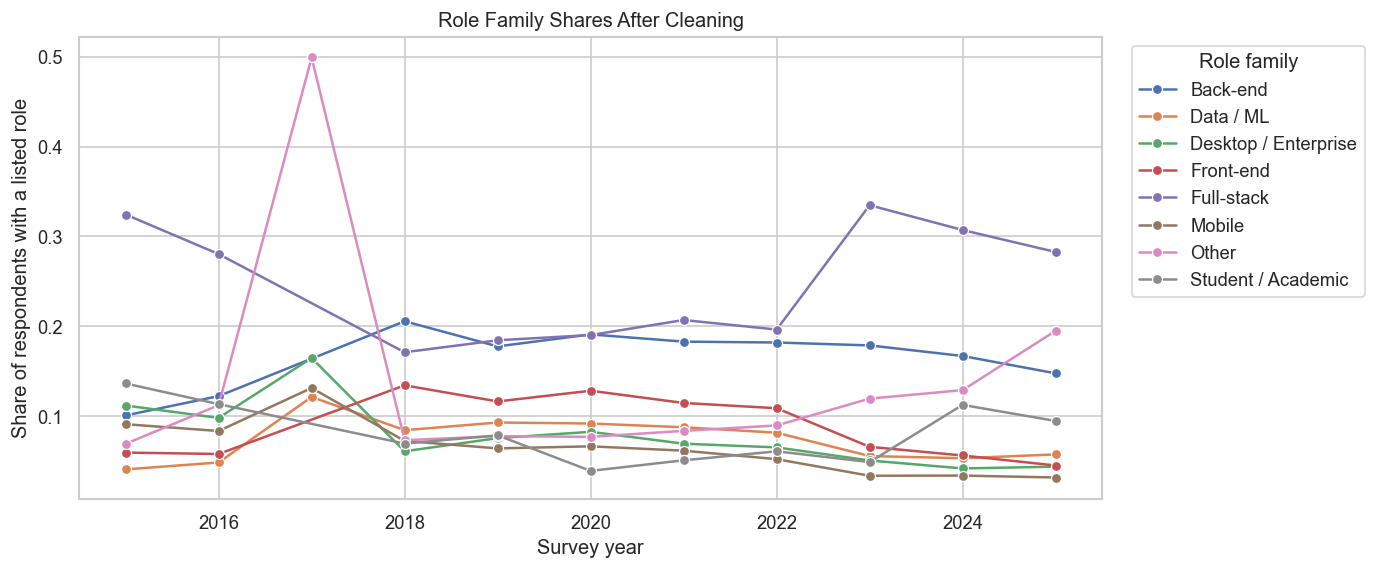

In [10]:
# Creates potential role groups for the various responses across the dataset
def role_family(token):
    if pd.isna(token):
        return pd.NA
    t = str(token).strip().lower()
    if "full-stack" in t:
        return "Full-stack"
    if "back-end" in t or "backend" in t or "server" in t:
        return "Back-end"
    if "front-end" in t or "frontend" in t:
        return "Front-end"
    if "data" in t or "machine learning" in t or "scientist" in t or "analyst" in t:
        return "Data / ML"
    if "mobile" in t or "ios" in t or "android" in t:
        return "Mobile"
    if (
        "devops" in t
        or "site reliability" in t
        or "cloud" in t
        or "system administrator" in t
    ):
        return "DevOps / Cloud"
    if "desktop" in t or "enterprise" in t:
        return "Desktop / Enterprise"
    if "manager" in t or "executive" in t:
        return "Management"
    if "student" in t or "academic researcher" in t or "educator" in t:
        return "Student / Academic"
    if "qa" in t or "quality assurance" in t or "test" in t:
        return "QA / Testing"
    return "Other"


# The roles are often multiselect columns with values separated by semicolons, this handles that
roles_long = clean.loc[clean["dev_type"].notna(), ["row_id", "survey_year", "dev_type"]].copy()
roles_long["dev_type"] = roles_long["dev_type"].astype(str).str.split(";")
roles_long = roles_long.explode("dev_type")
roles_long["dev_type"] = roles_long["dev_type"].str.strip()
roles_long = roles_long.loc[roles_long["dev_type"].ne("")].copy()
roles_long["role_family"] = roles_long["dev_type"].map(role_family)

clean = clean.drop(columns=[col for col in clean.columns if col.startswith("role_")], errors="ignore")
clean = clean.drop(columns=["role_family_count"], errors="ignore")

# Add the created role families to the correct rows and merge it back to the main frame
role_flags = pd.crosstab(roles_long["row_id"], roles_long["role_family"]).clip(upper=1)
role_flags.columns = [
    "role_" + re.sub(r"[^a-z0-9]+", "_", col.lower()).strip("_")
    for col in role_flags.columns
]
clean = clean.merge(role_flags.reset_index(), on="row_id", how="left")
role_cols = sorted([col for col in clean.columns if col.startswith("role_")])
clean[role_cols] = clean[role_cols].fillna(0).astype(int)
clean["role_family_count"] = clean[role_cols].sum(axis=1)


# Show top role counts
role_counts = clean[role_cols].sum().sort_values(ascending=False).rename("n")
display(role_counts.to_frame().head(15))

clean_cols = [
    "row_id",
    "survey_year",
    "response_id",
    "country",
    "country_clean",
    "region",
    "age",
    "age_mid",
    "age_group",
    "gender",
    "ethnicity",
    "main_branch",
    "student",
    "employment",
    "employment_group",
    "is_employed",
    "is_professional",
    "education",
    "education_clean",
    "undergrad_major",
    "age_first_code",
    "age_first_code_clean",
    "org_size",
    "org_size_clean",
    "dev_type",
    "industry",
    "remote",
    "remote_group",
    "job_seek",
    "work_week_hrs",
    "work_week_hrs_clean",
    "learn_code",
    "learn_code_online",
    "coding_activities",
    "language",
    "database",
    "platform",
    "webframe",
    "misc_tech",
    "op_sys_prof",
    "current_tech",
    "ai_use",
    "ai_sent",
    "language_count",
    "database_count",
    "platform_count",
    "webframe_count",
    "misc_tech_count",
    "years_code",
    "years_code_clean",
    "years_code_pro",
    "work_exp",
    "professional_experience_years",
    "job_sat",
    "job_sat_num",
    "comp",
    "comp_usd_clean",
    "log_comp_usd_clean",
    "is_comp_analysis_sample",
    "is_comp_model_core",
    "is_comp_model_tech_rich",
    "is_comp_model_ai_era",
    "is_comp_model_extended",
    "is_comp_model_sample",
    "role_family_count",
] + role_cols
clean_core = clean[clean_cols].copy()


# Show new cleaned coverage of usable features and a sample of them
coverage_cols = [
    "country_clean",
    "region",
    "employment_group",
    "age_mid",
    "gender",
    "ethnicity",
    "education_clean",
    "undergrad_major",
    "age_first_code_clean",
    "job_sat",
    "work_week_hrs_clean",
    "language",
    "database",
    "platform",
    "webframe",
    "misc_tech",
    "learn_code_online",
    "coding_activities",
    "op_sys_prof",
    "ai_use",
    "ai_sent",
    "org_size_clean",
    "remote_group",
    "professional_experience_years",
    "comp_usd_clean",
]
display((clean_core.groupby("survey_year")[coverage_cols].apply(lambda frame: frame.notna().mean())* 100).round(1))
print(clean_core.shape)
display(clean_core.sample(5, random_state=42))


# Get share of roles across the years
role_prev = (
    roles_long.groupby(["survey_year", "role_family"])["row_id"]
    .nunique()
    .rename("respondents")
    .reset_index()
)
role_prev["share"] = role_prev["respondents"] / role_prev.groupby("survey_year")["respondents"].transform("sum")
top_roles = role_prev.groupby("role_family")["respondents"].sum().nlargest(8).index
role_prev = role_prev.loc[role_prev["role_family"].isin(top_roles)]


# Visual role share trends
plt.figure(figsize=(11, 5))
sns.lineplot(data=role_prev, x="survey_year", y="share", hue="role_family", marker="o")
plt.title("Role Family Shares After Cleaning")
plt.xlabel("Survey year")
plt.ylabel("Share of respondents with a listed role")
plt.legend(title="Role family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## Next Steps

This gets us to a usable cleaning baseline. The next notebook will focus on stricter country QA, deciding the final compensation model window, and adding inflation adjustment for real cross-year compensation comparisons. Then it will begin preprocessing and setting up the models.